# Generador de mapas Buscaminas para MARIE (Google Colab, version simple)

Este notebook corre sin montar Drive y sin manejo complejo de excepciones.

Flujo al ejecutar Run all:
1. Descarga input/base_game.mas desde Google Drive usando file_id.
2. Genera la matriz 16x16 de Buscaminas (12 minas).
3. Inyecta la matriz en la plantilla Assembly con el marcador {{BOARD_TILES_PLACEHOLDER}}.
4. Guarda output/generated_game.mas y output/board_preview.png en /content/output.

Nota: BASE_GAME_FILE_ID debe ser del archivo base_game.mas (compartido por enlace).

In [1]:
import gdown
from pathlib import Path
import random
from typing import List, Sequence

GRID_SIZE = 16
MINE_COUNT = 12
PLACEHOLDER = "{{BOARD_TILES_PLACEHOLDER}}"
CELL_SIZE = 40
SEED = None

BASE_GAME_FILE_ID = "1MBRFvRaJioUfg3TnR96TYVmOA-g3WMtA"

project_root = Path("/content")
input_dir = project_root / "input"
output_dir = project_root / "output"
input_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

base_file = input_dir / "base_game.mas"
generated_file = output_dir / "generated_game.mas"
preview_file = output_dir / "board_preview.png"

# Usamos gdown que maneja automaticamente el aviso de virus de Google Drive
url = f"https://drive.google.com/uc?id={BASE_GAME_FILE_ID}"
gdown.download(url, str(base_file), quiet=False)

# Verificacion
content = base_file.read_text(encoding="utf-8")
print(f"\nInput: {base_file}")
print(f"Contenido (primeros 100 caracteres): {content[:100]}")
if "<!DOCTYPE html>" in content:
    print("\nERROR: Sigue siendo HTML. Verifica los permisos de acceso del archivo en Drive.")
else:
    print("\n¡Éxito! El archivo se ha descargado correctamente.")

Downloading...
From (original): https://drive.google.com/uc?id=1MBRFvRaJioUfg3TnR96TYVmOA-g3WMtA
From (redirected): https://drive.google.com/uc?id=1MBRFvRaJioUfg3TnR96TYVmOA-g3WMtA&confirm=t&uuid=7aa1c9fc-6d7c-4638-a622-cb0e18e7e075
To: /content/input/base_game.mas
100%|██████████| 15.9k/15.9k [00:00<00:00, 3.86MB/s]


Input: /content/input/base_game.mas
Contenido (primeros 100 caracteres): 
					Jump		Start

/ Color Values
COLOR_UNKNOWN,		HEX			2108 / Dark Gray
COLOR_FLAG,			HEX			7FE0 / 

¡Éxito! El archivo se ha descargado correctamente.


In [2]:
# 2: Generacion matematica del tablero Buscaminas
def generate_board(size: int, mine_count: int, rng: random.Random) -> List[List[int]]:
    if mine_count >= size * size:
        raise ValueError("mine_count debe ser menor que el total de casillas")

    board = [[0 for _ in range(size)] for _ in range(size)]
    mine_positions = rng.sample(range(size * size), mine_count)

    for idx in mine_positions:
        r, c = divmod(idx, size)
        board[r][c] = -1

    # Incrementa vecinos de cada mina (8 direcciones)
    for idx in mine_positions:
        r, c = divmod(idx, size)
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < size and 0 <= nc < size and board[nr][nc] != -1:
                    board[nr][nc] += 1

    return board


def flatten_board(board: Sequence[Sequence[int]]) -> List[int]:
    # Orden fila por fila: izquierda a derecha, arriba a abajo
    return [value for row in board for value in row]


rng = random.Random(SEED)
board = generate_board(GRID_SIZE, MINE_COUNT, rng)
flat_values = flatten_board(board)

if len(flat_values) != GRID_SIZE * GRID_SIZE:
    raise RuntimeError("La matriz aplanada no tiene 256 elementos")

mine_total = sum(1 for x in flat_values if x == -1)
print(f"Minas colocadas: {mine_total}")
print(f"Total de casillas: {len(flat_values)}")
print("Primeros 24 valores aplanados:", flat_values[:24])

Minas colocadas: 12
Total de casillas: 256
Primeros 24 valores aplanados: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0]


In [3]:
# 3: Inyeccion en plantilla MARIE Assembly y guardado de .mas
# 3: Inyeccion en plantilla MARIE Assembly y guardado de .mas
import re

def board_to_marie_dec(values: Sequence[int]) -> str:
    return "\n".join(f"DEC {value}" for value in values)


def inject_board_into_template(template_text: str, board_dec_lines: str) -> str:
    # Caso A: plantilla con marcador explicito
    if PLACEHOLDER in template_text:
        return template_text.replace(PLACEHOLDER, board_dec_lines)

    # Caso B: plantilla sin marcador, pero con seccion BoardTiles ya definida
    # Reemplaza desde 'BoardTiles,' hasta antes de la siguiente etiqueta (ej. MINE_COUNT,)
    pattern = r"(BoardTiles,\s*)(?:DEC\s+-?\d+\s*)+(\n\s*[A-Za-z_][A-Za-z0-9_]*,\s*)"
    replacement = r"\1" + board_dec_lines + r"\n\2"
    updated_text, replacements = re.subn(pattern, replacement, template_text, count=1, flags=re.MULTILINE)

    if replacements == 1:
        return updated_text

    raise ValueError(
        "No se encontro {{BOARD_TILES_PLACEHOLDER}} ni una seccion BoardTiles valida para reemplazar."
    )


try:
    template_text = base_file.read_text(encoding="utf-8")
    board_dec = board_to_marie_dec(flat_values)
    generated_asm = inject_board_into_template(template_text, board_dec)
    generated_file.write_text(generated_asm, encoding="utf-8")
except OSError as exc:
    raise RuntimeError(f"Error de lectura/escritura de archivos: {exc}") from exc

print("Archivo Assembly generado correctamente.")
print(f"Ruta: {generated_file}")
print("Vista previa de lineas DEC (primeras 12):")
print("\n".join(board_dec.splitlines()[:12]))

Archivo Assembly generado correctamente.
Ruta: /content/output/generated_game.mas
Vista previa de lineas DEC (primeras 12):
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0
DEC 0


In [4]:
# 4: Render de la imagen del tablero (board_preview.png)
try:
    from PIL import Image, ImageDraw, ImageFont
except ImportError:
    # En Colab, instala Pillow automaticamente si hace falta.
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "Pillow"])
    from PIL import Image, ImageDraw, ImageFont

TILE_STYLES = {
    -1: ("#000000", "#FFFFFF"),  # Mina
    0: ("#D3D3D3", "#000000"),
    1: ("#0000FF", "#FFFFFF"),
    2: ("#008000", "#FFFFFF"),
    3: ("#FF0000", "#FFFFFF"),
    4: ("#00008B", "#FFFFFF"),
    5: ("#8B0000", "#FFFFFF"),
    6: ("#00CCCC", "#000000"),
    7: ("#800080", "#FFFFFF"),
    8: ("#FFFFFF", "#000000"),
}


def render_board_image(board_data: Sequence[Sequence[int]], output_path: Path, cell_size: int = 40) -> None:
    size = len(board_data)
    img_w = size * cell_size
    img_h = size * cell_size

    image = Image.new("RGB", (img_w, img_h), "#FFFFFF")
    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.truetype("arial.ttf", int(cell_size * 0.5))
    except OSError:
        font = ImageFont.load_default()

    for row in range(size):
        for col in range(size):
            value = board_data[row][col]
            bg, fg = TILE_STYLES[value]

            x0 = col * cell_size
            y0 = row * cell_size
            x1 = x0 + cell_size
            y1 = y0 + cell_size

            draw.rectangle([x0, y0, x1, y1], fill=bg, outline="#404040", width=1)

            label = "M" if value == -1 else str(value)
            left, top, right, bottom = draw.textbbox((0, 0), label, font=font)
            text_w = right - left
            text_h = bottom - top

            text_x = x0 + (cell_size - text_w) / 2
            text_y = y0 + (cell_size - text_h) / 2
            draw.text((text_x, text_y), label, fill=fg, font=font)

    image.save(output_path)


render_board_image(board, preview_file, CELL_SIZE)
print("Imagen generada correctamente.")
print(f"Ruta: {preview_file}")

Imagen generada correctamente.
Ruta: /content/output/board_preview.png


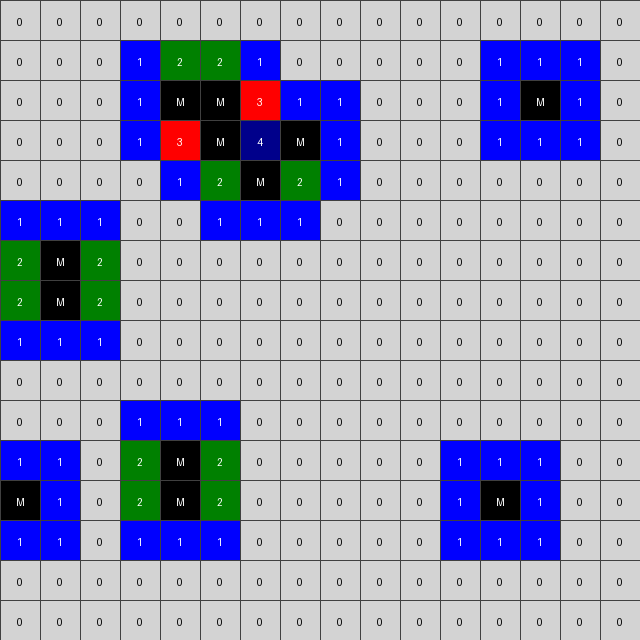

In [5]:
from IPython.display import display
display(Image.open(preview_file))

In [6]:
# 6: Descarga opcional de resultados en Colab
from google.colab import files

files.download(str(generated_file))
files.download(str(preview_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>